In [4]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
#LOAD DATA
df = pd.read_csv("online_retail.csv", encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
#DATA OVERVIEW
print("Shape:", df.shape)
print("\nInfo:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (541909, 8)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [7]:
#DATA CLEANING
# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove negative or zero values
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Remove duplicates
df = df.drop_duplicates()

# Convert data types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [8]:
#FEATURE ENGINEERING
# Create Total Price
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df[['Quantity','UnitPrice','TotalPrice']].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [9]:
#RFM CALCULATION
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [10]:
#RFM SUMMARY
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [11]:
#FEATURE SCALING
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled[:5]

array([[ 2.33457414, -0.4250965 ,  8.36301037],
       [-0.90534032,  0.3544168 ,  0.2516989 ],
       [-0.17535959, -0.03533985, -0.02798783],
       [-0.73534481, -0.4250965 , -0.03240559],
       [ 2.17457836, -0.4250965 , -0.19081155]])

In [12]:
#K-MEANS CLUSTERING
kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,326,1,77183.60,1
12347,2,7,4310.00,0
12348,75,4,1797.24,0
12349,19,1,1757.55,0
12350,310,1,334.40,1


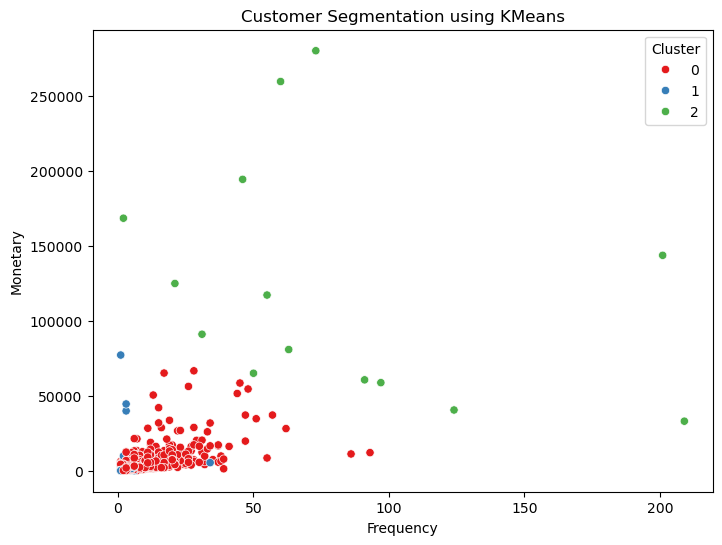

In [33]:
#Customer Segmentation using KMeans
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=rfm['Frequency'],
    y=rfm['Monetary'],
    hue=rfm['Cluster'],
    palette='Set1'
)

plt.title("Customer Segmentation using KMeans")
plt.xlabel("Frequency")
plt.ylabel("Monetary")

plt.show()

In [13]:
#SEGMENT LABELING
def segment(row):
    if row['Monetary'] > 1000 and row['Frequency'] > 10:
        return 'High Value'
    elif row['Recency'] > 90:
        return 'At Risk'
    else:
        return 'Regular'

rfm['Segment'] = rfm.apply(segment, axis=1)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346,326,1,77183.60,1,At Risk
12347,2,7,4310.00,0,Regular
12348,75,4,1797.24,0,Regular
12349,19,1,1757.55,0,Regular
12350,310,1,334.40,1,At Risk


In [14]:
#CHURN CREATION
rfm['Churn'] = (rfm['Recency'] > 90).astype(int)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment,Churn
CustomerID,,,,,,
12346,326,1,77183.60,1,At Risk,1
12347,2,7,4310.00,0,Regular,0
12348,75,4,1797.24,0,Regular,0
12349,19,1,1757.55,0,Regular,0
12350,310,1,334.40,1,At Risk,1


In [15]:
#CUSTOMER LIFECYCLE
def lifecycle(x):
    if x <= 30:
        return "Active"
    elif x <= 90:
        return "Warm"
    else:
        return "Lost"

rfm['Lifecycle'] = rfm['Recency'].apply(lifecycle)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment,Churn,Lifecycle
CustomerID,,,,,,,
12346,326,1,77183.60,1,At Risk,1,Lost
12347,2,7,4310.00,0,Regular,0,Active
12348,75,4,1797.24,0,Regular,0,Warm
12349,19,1,1757.55,0,Regular,0,Active
12350,310,1,334.40,1,At Risk,1,Lost


In [35]:
#MACHINE LEARNING (RANDOM FOREST)
# Features and Target
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Churn']

# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest Model
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)

# Train Model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [17]:
#MODEL EVALUATION
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[561   0]
 [  0 307]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       561
           1       1.00      1.00      1.00       307

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



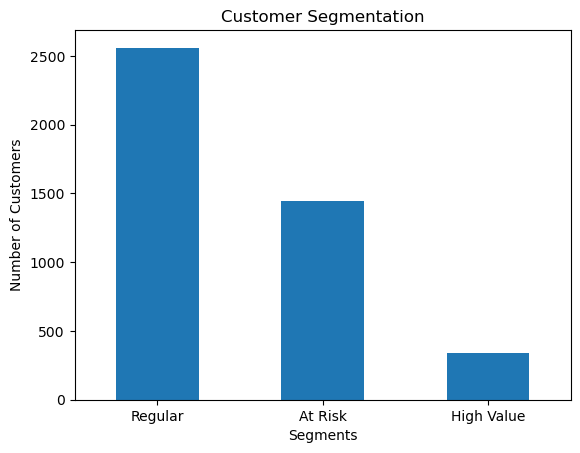

In [18]:
#CUSTOMER SEGMENTATION GRAPH
rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segmentation")
plt.xlabel("Segments")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [21]:
#Insight:
#- Customers are divided into High Value, Regular, and At Risk segments.
#- Majority customers belong to Regular category.
#- High-value customers contribute significantly to revenue.

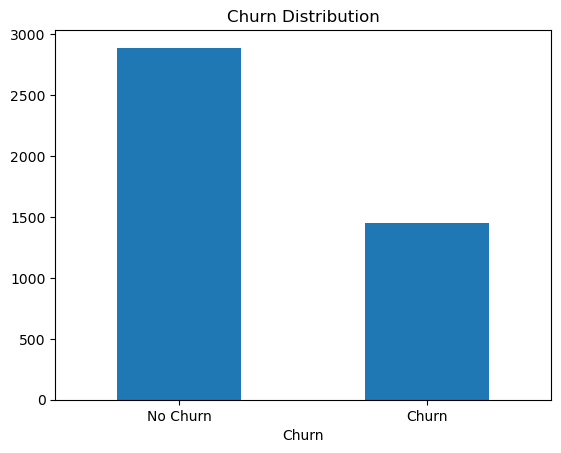

In [22]:
#CHURN GRAPH
rfm['Churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.xticks([0,1], ['No Churn','Churn'], rotation=0)
plt.show()

In [24]:
#Insight:
#- A noticeable percentage of customers are at risk of churn.
#- This indicates potential revenue loss.
#- Retention strategies are required.

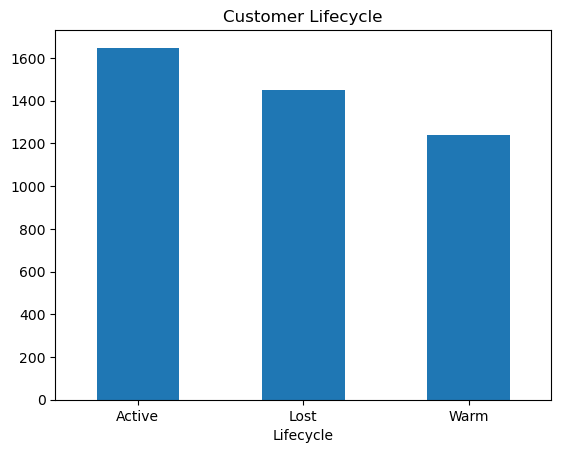

In [25]:
#CUSTOMER LIFECYCLE GRAPH
rfm['Lifecycle'].value_counts().plot(kind='bar')
plt.title("Customer Lifecycle")
plt.xlabel("Lifecycle")
plt.xticks(rotation=0)
plt.show()

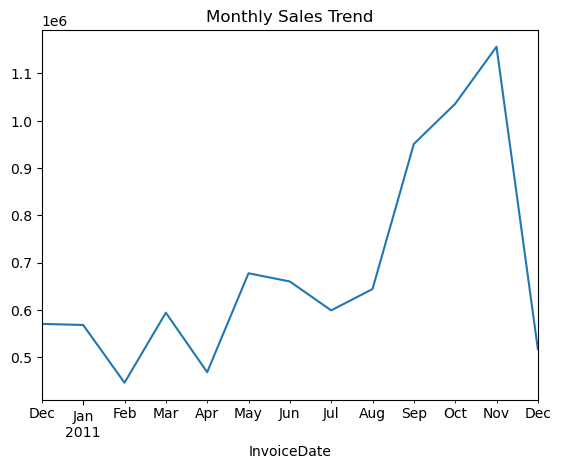

In [26]:
#SALES TREND
sales = df.groupby(df['InvoiceDate'].dt.to_period('M'))['TotalPrice'].sum()
sales.plot()
plt.title("Monthly Sales Trend")
plt.show()

In [ ]:
#Insight:
#- Sales show variation over time.
#- Indicates possible seasonal trends and business fluctuations.

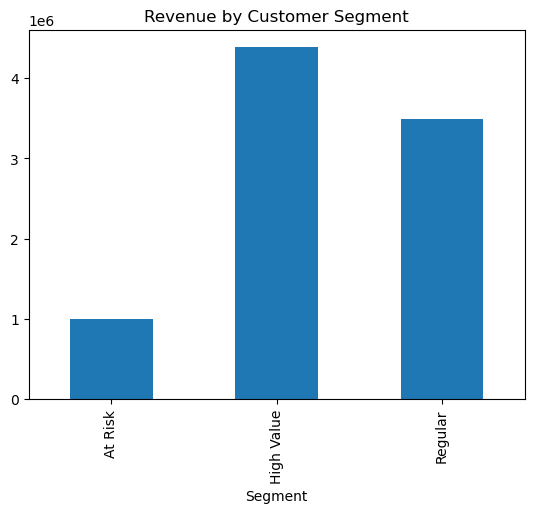

In [27]:
#REVENUE BY SEGMENT
rfm.groupby('Segment')['Monetary'].sum().plot(kind='bar')
plt.title("Revenue by Customer Segment")
plt.show()

In [28]:
#BUSINESS METRICS
total_customers = len(rfm)

high_value = (rfm['Segment'] == "High Value").sum()
churn_customers = rfm['Churn'].sum()

print("High Value %:", round(high_value / total_customers * 100, 2))
print("Churn %:", round(churn_customers / total_customers * 100, 2))

High Value %: 7.77
Churn %: 33.4


In [29]:
#FINAL OUTPUT TABLE
rfm.head(10)

,Recency,Frequency,Monetary,Cluster,Segment,Churn,Lifecycle
CustomerID,,,,,,,
12346,326,1,77183.60,1,At Risk,1,Lost
12347,2,7,4310.00,0,Regular,0,Active
12348,75,4,1797.24,0,Regular,0,Warm
12349,19,1,1757.55,0,Regular,0,Active
12350,310,1,334.40,1,At Risk,1,Lost
12352,36,8,2506.04,0,Regular,0,Warm
12353,204,1,89.00,1,At Risk,1,Lost
12354,232,1,1079.40,1,At Risk,1,Lost
12355,214,1,459.40,1,At Risk,1,Lost


In [30]:
# Export full final output table to Excel
# Merge RFM data back to original dataset

final_df = df.merge(rfm, on='CustomerID', how='left')

# Check final dataset
final_df.head()
final_df.to_csv("Final_Retail_Output.csv", index=False)

print("Final CSV file exported successfully!")

Final CSV file exported successfully!
